# Ideal Low Pass Filter (ILPF) — Step by Step
> Demonstrates frequency domain filtering using 2D DFT in Python

In [1]:
# Install dependencies if needed
%pip install numpy matplotlib opencv-python Pillow -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#0f0f1a'
plt.rcParams['text.color']       = '#e8e8ff'
plt.rcParams['axes.labelcolor']  = '#9090bb'
plt.rcParams['xtick.color']      = '#555577'
plt.rcParams['ytick.color']      = '#555577'

print('✅ Libraries loaded')

✅ Libraries loaded


## Step 1 — Load & Display the Original Image

Image size: 224 × 280 px


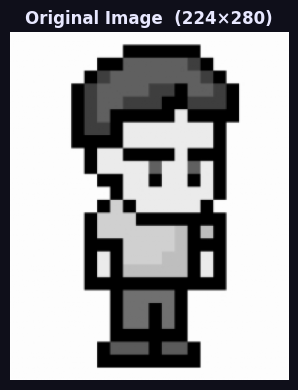

In [3]:
IMAGE_PATH = 'image.png'   # <-- change path if needed

img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32)
H, W = img.shape
print(f'Image size: {W} × {H} px')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap='gray')
ax.set_title(f'Original Image  ({W}×{H})', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2 — Compute 2D DFT & Shift Zero-Frequency to Center

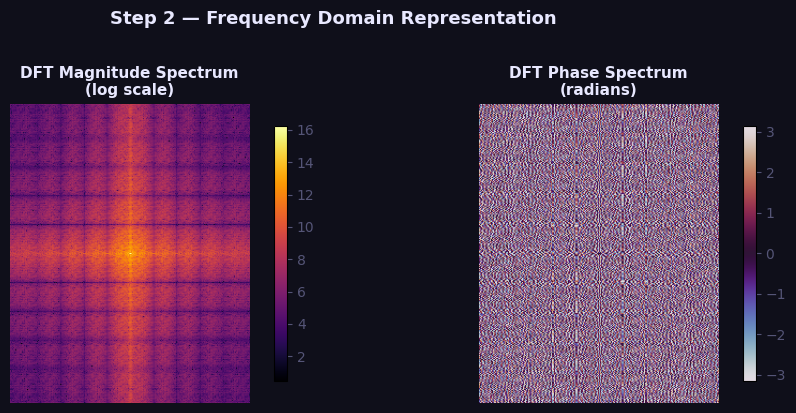

💡 Bright center = low frequencies (background/flat regions)
💡 Bright edges  = high frequencies (sharp edges, fine detail)


In [14]:
# 2D Fast Fourier Transform
dft       = np.fft.fft2(img)

# Shift so that DC (zero-frequency) is at the center
dft_shift = np.fft.fftshift(dft)

# Magnitude spectrum (log scale for visibility)
magnitude    = np.abs(dft_shift)
log_mag      = np.log1p(magnitude)

# Phase spectrum
phase        = np.angle(dft_shift)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(log_mag, cmap='inferno')
axes[0].set_title('DFT Magnitude Spectrum\n(log scale)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('low ← frequency → high')
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(phase, cmap='twilight')
axes[1].set_title('DFT Phase Spectrum\n(radians)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.85)

for ax in axes:
    ax.axis('off')

plt.suptitle('Step 2 — Frequency Domain Representation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Bright center = low frequencies (background/flat regions)')
print('💡 Bright edges  = high frequencies (sharp edges, fine detail)')

## Step 3 — Create the Ideal LPF Mask

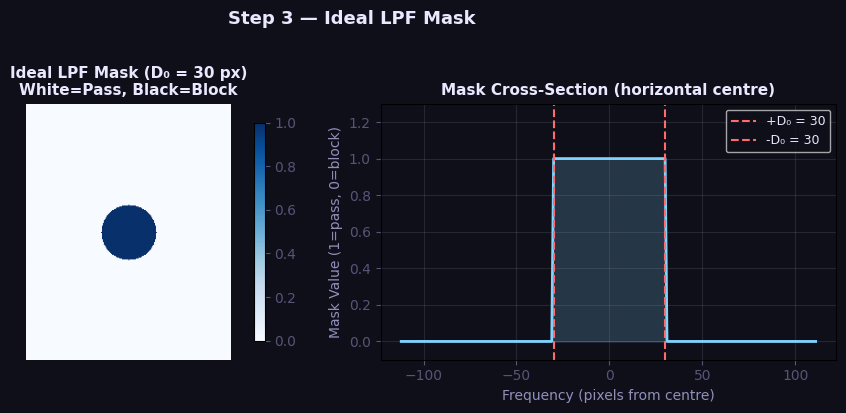

💡 Hard cutoff at D₀=30: this "brick wall" causes Gibbs (ringing) artifacts


In [5]:
def ideal_lpf_mask(shape, D0):
    """Binary circular mask: 1 inside radius D0 (pass), 0 outside (block)."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    return (dist <= D0).astype(np.float32)

D0 = 30   # ← cutoff radius in pixels (change this to experiment)
mask = ideal_lpf_mask(img.shape, D0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 2D mask
im = axes[0].imshow(mask, cmap='Blues')
axes[0].set_title(f'Ideal LPF Mask (D₀ = {D0} px)\nWhite=Pass, Black=Block', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0], shrink=0.85)
axes[0].axis('off')

# 1D cross-section
mid = mask[H // 2, :]
xs  = np.arange(W) - W // 2
axes[1].plot(xs, mid, color='#7fd4ff', linewidth=2)
axes[1].axvline( D0, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'+D₀ = {D0}')
axes[1].axvline(-D0, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'-D₀ = {D0}')
axes[1].fill_between(xs, mid, alpha=0.2, color='#7fd4ff')
axes[1].set_title('Mask Cross-Section (horizontal centre)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Frequency (pixels from centre)')
axes[1].set_ylabel('Mask Value (1=pass, 0=block)')
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.15)

plt.suptitle('Step 3 — Ideal LPF Mask', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'💡 Hard cutoff at D₀={D0}: this "brick wall" causes Gibbs (ringing) artifacts')

## Step 4 — Apply Mask & View Filtered Spectrum

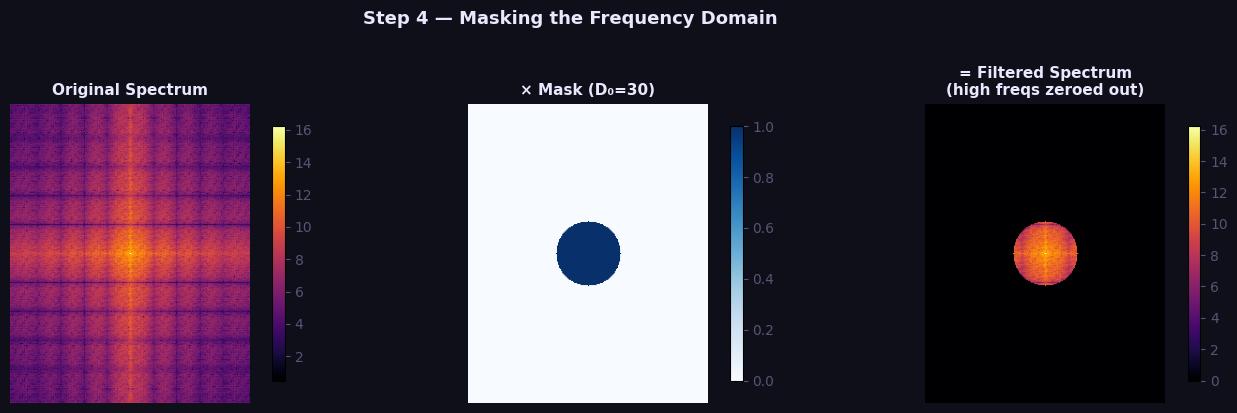

In [17]:
# Element-wise multiply spectrum by mask
filtered_shift = dft_shift * mask
filtered_log   = np.log1p(np.abs(filtered_shift))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(log_mag, cmap='inferno')
axes[0].set_title('Original Spectrum', fontsize=11, fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(mask, cmap='Blues')
axes[1].set_title(f'× Mask (D₀={D0})', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(filtered_log, cmap='inferno')
axes[2].set_title('= Filtered Spectrum\n(high freqs zeroed out)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 4 — Masking the Frequency Domain', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5 — Inverse DFT → Filtered Image

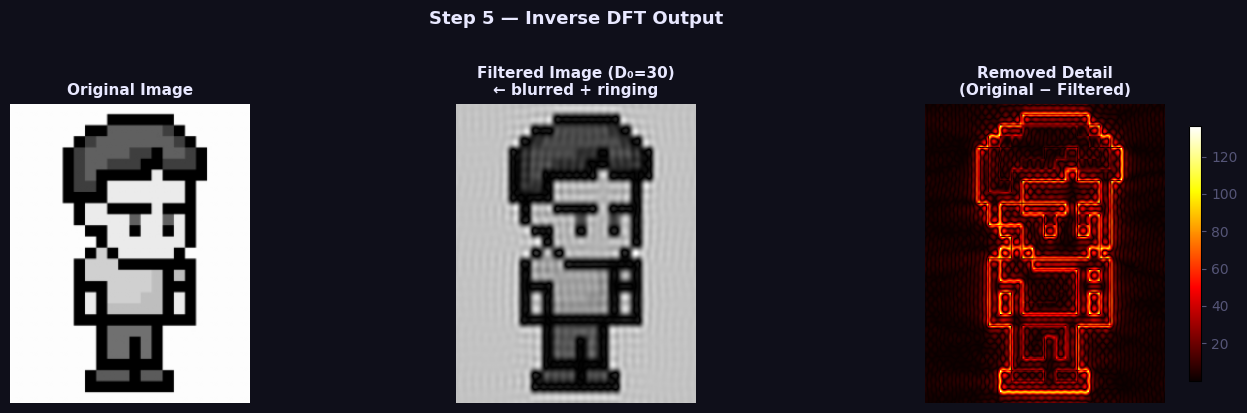

💡 Blurring = low-pass effect. Ringing = Gibbs artifact from hard cutoff.
💡 Removed detail shows sharp edges and pixel-art boundaries.


In [7]:
# Inverse shift + Inverse DFT
filtered_dft = np.fft.ifftshift(filtered_shift)
filtered_img = np.abs(np.fft.ifft2(filtered_dft))

# What was removed (high-frequency detail)
diff = np.abs(img - filtered_img)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image', fontsize=11, fontweight='bold')

axes[1].imshow(filtered_img, cmap='gray')
axes[1].set_title(f'Filtered Image (D₀={D0})\n← blurred + ringing', fontsize=11, fontweight='bold')

im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Removed Detail\n(Original − Filtered)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 5 — Inverse DFT Output', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Blurring = low-pass effect. Ringing = Gibbs artifact from hard cutoff.')
print('💡 Removed detail shows sharp edges and pixel-art boundaries.')

## Step 6 — Compare Multiple Cutoff Radii (D₀)

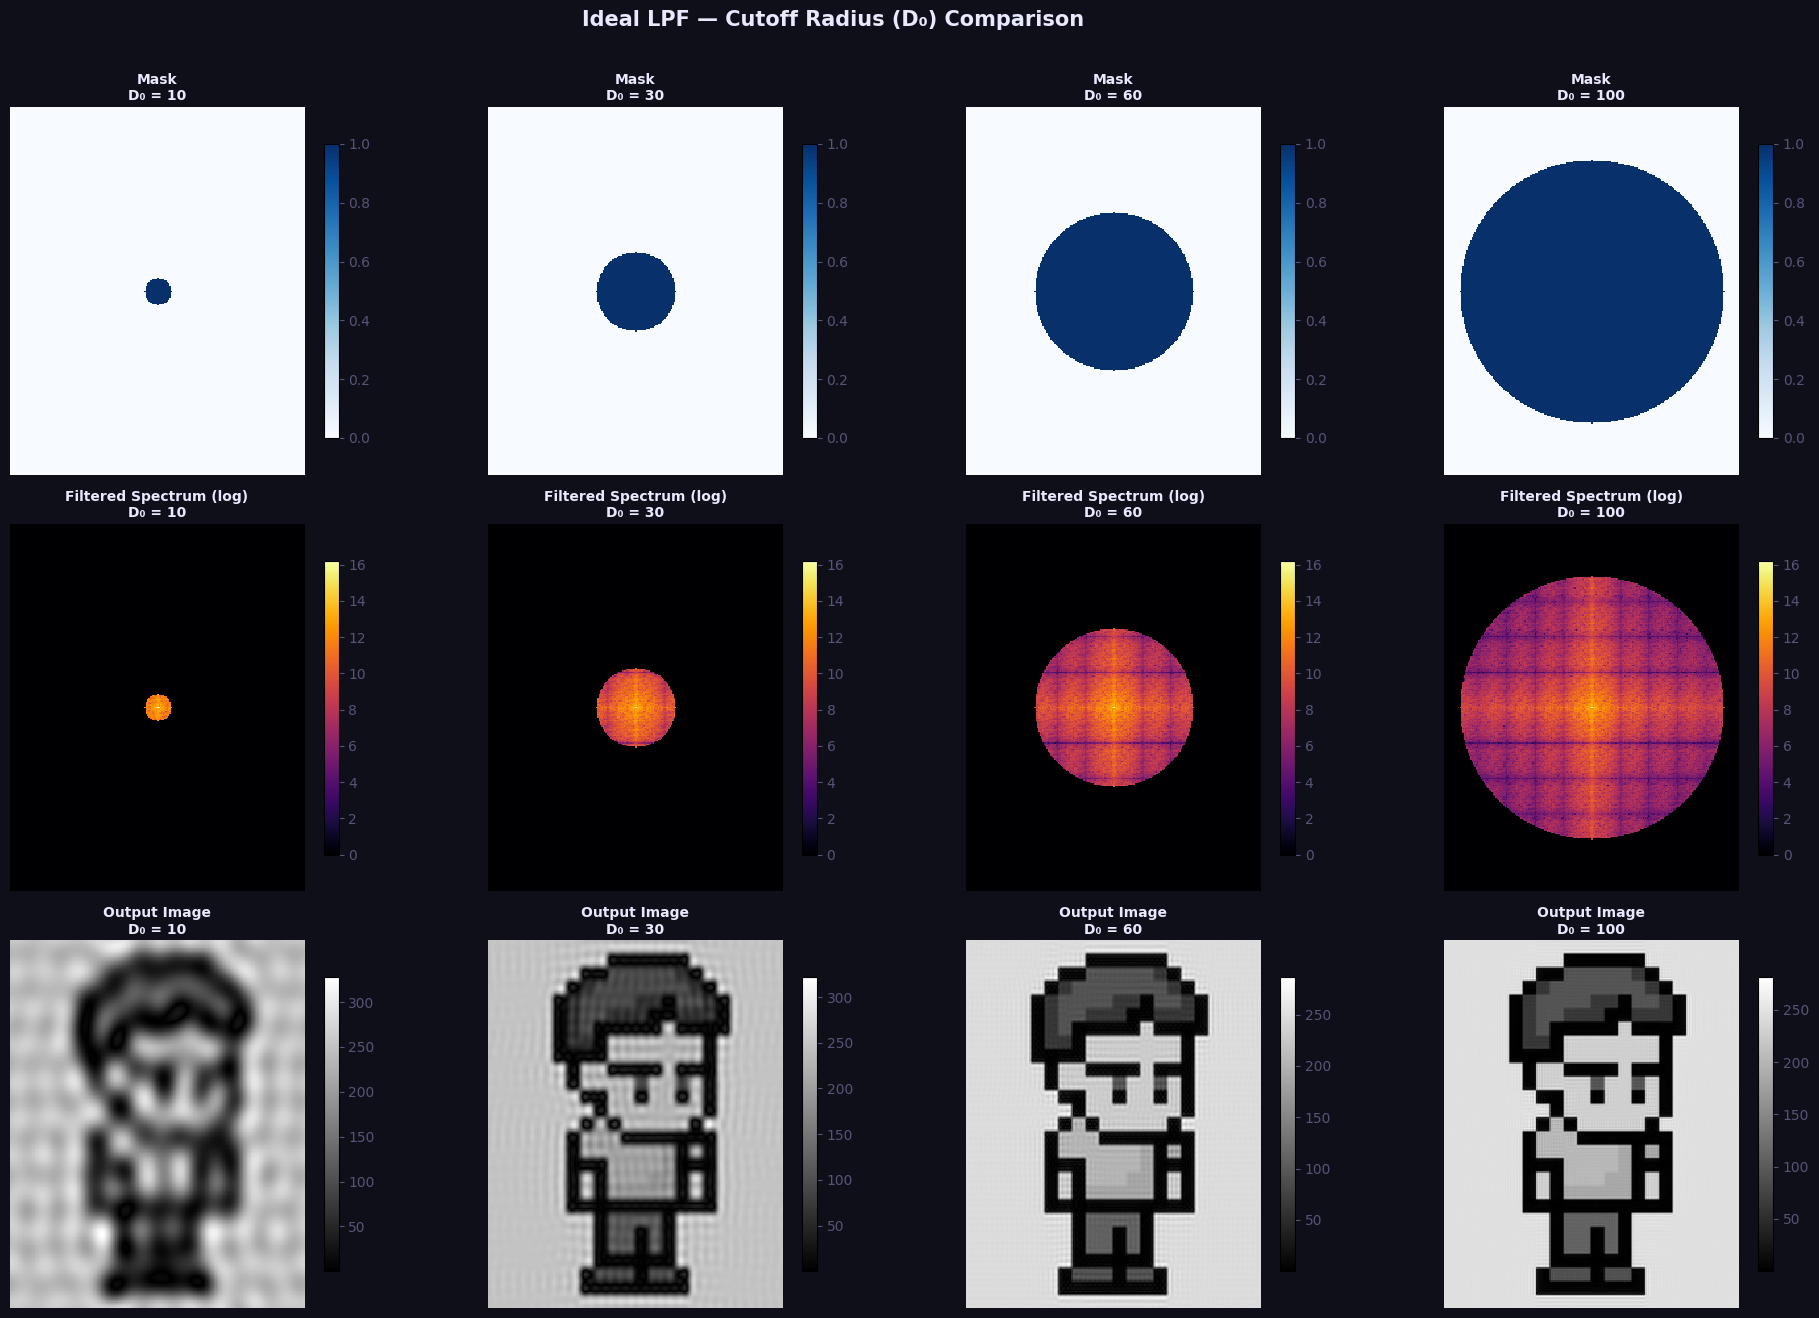

💡 Small D₀  → more blurry, stronger ringing, fewer frequencies pass
💡 Large D₀  → less blurry, closer to original, most frequencies pass


In [8]:
CUTOFF_RADII = [10, 30, 60, 100]

fig, axes = plt.subplots(3, len(CUTOFF_RADII), figsize=(5 * len(CUTOFF_RADII), 13))
row_titles = ['Mask', 'Filtered Spectrum (log)', 'Output Image']
cmaps      = ['Blues', 'inferno', 'gray']

for col, D0_val in enumerate(CUTOFF_RADII):
    m          = ideal_lpf_mask(img.shape, D0_val)
    fs         = dft_shift * m
    fml        = np.log1p(np.abs(fs))
    fi         = np.abs(np.fft.ifft2(np.fft.ifftshift(fs)))

    for row, (data, cmap) in enumerate(zip([m, fml, fi], cmaps)):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, interpolation='nearest')
        ax.set_title(f'{row_titles[row]}\nD₀ = {D0_val}', fontsize=10, fontweight='bold', pad=5)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)

plt.suptitle('Ideal LPF — Cutoff Radius (D₀) Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Small D₀  → more blurry, stronger ringing, fewer frequencies pass')
print('💡 Large D₀  → less blurry, closer to original, most frequencies pass')

## Step 7 — Interactive: Try Your Own D₀

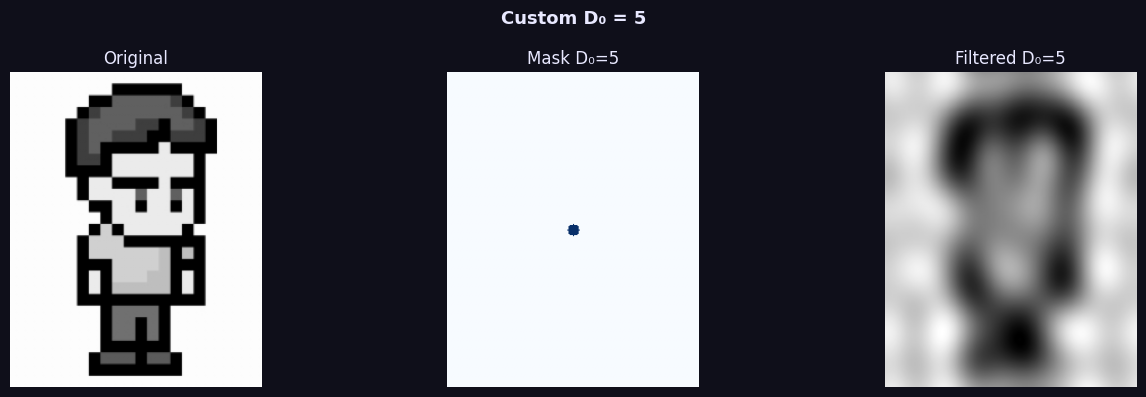

In [19]:
# Change D0_custom below and re-run this cell to experiment
D0_custom = 5   # ← try values like 5, 15, 40, 80, 120

m_c  = ideal_lpf_mask(img.shape, D0_custom)
fs_c = dft_shift * m_c
fi_c = np.abs(np.fft.ifft2(np.fft.ifftshift(fs_c)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img,                      cmap='gray');    axes[0].set_title('Original')
axes[1].imshow(m_c,                      cmap='Blues');   axes[1].set_title(f'Mask D₀={D0_custom}')
axes[2].imshow(fi_c,                     cmap='gray');    axes[2].set_title(f'Filtered D₀={D0_custom}')
for ax in axes: ax.axis('off')
plt.suptitle(f'Custom D₀ = {D0_custom}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()